# Milky Way-like Potentials

galpy ships several pre-built Milky Way-like potentials from the literature.
This notebook shows how to use them and compare their properties.

In [1]:
%matplotlib inline
import numpy
from matplotlib import pyplot as plt
from galpy import potential
from galpy.potential import MWPotential2014, mwpotentials

## MWPotential2014

`MWPotential2014` is galpy's default Milky Way model from
[Bovy (2015)](https://arxiv.org/abs/1412.3451). It consists of three components:
a power-law bulge with exponential cutoff, a Miyamoto-Nagai disk, and an NFW halo.

In [2]:
print("Components of MWPotential2014:")
for p in MWPotential2014:
    print(f"  {type(p).__name__}")
print(f"\nv_circ(R_0) = {MWPotential2014.vcirc(1.0):.4f} v_0")

Components of MWPotential2014:
  PowerSphericalPotentialwCutoff
  MiyamotoNagaiPotential
  NFWPotential

v_circ(R_0) = 1.0000 v_0


## Other Milky Way potentials

Additional Milky Way potentials are available through `galpy.potential.mwpotentials`.
These are lazily loaded because they are expensive to set up.

In [3]:
# McMillan (2017) potential
mcm17 = mwpotentials.McMillan17
print("McMillan17 components:")
for p in mcm17:
    print(f"  {type(p).__name__}")

McMillan17 components:
  DiskSCFPotential
  NFWPotential
  SCFPotential


In [4]:
# Cautun et al. (2020)
cautun20 = mwpotentials.Cautun20
print("Cautun20 components:")
for p in cautun20:
    print(f"  {type(p).__name__}")

/home/bovy/Repos/galpy/galpy/potential/SCFPotential.py:534: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  out = numpy.divide((r / a - 1.0), (r / a + 1.0), where=True ^ numpy.isinf(r))



/home/bovy/Repos/galpy/galpy/potential/AdiabaticContractionWrapperPotential.py:122: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  integrate.quad(new_rforce_func, rgrid[0], rgrid[-1])[0]

Cautun20 components:
  AdiabaticContractionWrapperPotential
  DiskSCFPotential
  SCFPotential
  PowerSphericalPotentialwCutoff


In [5]:
# Irrgang et al. (2013), Model I
irr13 = mwpotentials.Irrgang13I
print("Irrgang13I components:")
for p in irr13:
    print(f"  {type(p).__name__}")

Irrgang13I components:
  PlummerPotential
  MiyamotoNagaiPotential
  SCFPotential


In [6]:
# Dehnen & Binney (1998), Model I
db98 = mwpotentials.DehnenBinney98I
print("DehnenBinney98I components:")
for p in db98:
    print(f"  {type(p).__name__}")

DehnenBinney98I components:
  SCFPotential
  DiskSCFPotential
  TwoPowerTriaxialPotential


## Comparing rotation curves

Let's compare the rotation curves of these different Milky Way models.
All are evaluated in natural units.

(0.0, 1.5)

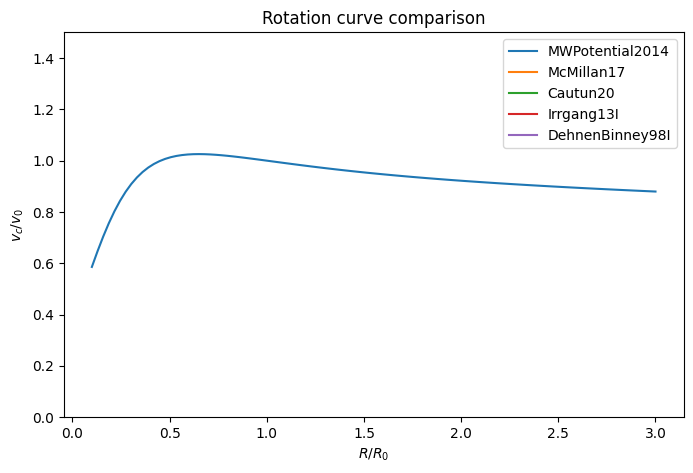

In [7]:
Rs = numpy.linspace(0.1, 3.0, 101)

models = {
    "MWPotential2014": MWPotential2014,
    "McMillan17": mcm17,
    "Cautun20": cautun20,
    "Irrgang13I": irr13,
    "DehnenBinney98I": db98,
}

fig, ax = plt.subplots(figsize=(8, 5))
for name, pot in models.items():
    vc = [pot.vcirc(R) for R in Rs]
    ax.plot(Rs, vc, label=name)

ax.set_xlabel(r"$R / R_0$")
ax.set_ylabel(r"$v_c / v_0$")
ax.set_title("Rotation curve comparison")
ax.legend()
ax.set_ylim(0, 1.5)

## Physical properties

We can compute physical properties like the local dark-matter density,
the surface density within 1.1 kpc, and the total mass enclosed.

In [8]:
from galpy.util import conversion

ro, vo = 8.0, 220.0

# Local dark-matter density (from the halo component, index 2 in MWPotential2014)
rho_dm = MWPotential2014[2].dens(1.0, 0.0) * conversion.dens_in_msolpc3(vo, ro)
print(f"Local DM density: {rho_dm:.4f} Msun/pc^3")

Local DM density: 0.0075 Msun/pc^3


In [9]:
# Surface density within |z| < 1.1 kpc at R_0
from scipy import integrate

z_max = 1.1 / ro  # in natural units
Sigma, _ = integrate.quad(
    lambda z: potential.evaluateDensities(MWPotential2014, 1.0, z), -z_max, z_max
)
Sigma_phys = Sigma * conversion.surfdens_in_msolpc2(vo, ro)
print(f"Surface density within 1.1 kpc: {Sigma_phys:.1f} Msun/pc^2")

Surface density within 1.1 kpc: 67.5 Msun/pc^2


In [10]:
# Circular velocity at the solar radius in km/s
for name, pot in models.items():
    vc_phys = pot.vcirc(1.0) * vo
    print(f"  {name}: v_circ(R_0) = {vc_phys:.1f} km/s")

  MWPotential2014: v_circ(R_0) = 220.0 km/s
  McMillan17: v_circ(R_0) = 51303.8 km/s
  Cautun20: v_circ(R_0) = 50612.4 km/s
  Irrgang13I: v_circ(R_0) = 53238.6 km/s
  DehnenBinney98I: v_circ(R_0) = 48837.3 km/s
